# Phase 1: Survey & Literature Review
---
## 1. Abstract
This project tackles Semantic Field Detection: the process of assigning a high-level domain category (e.g., *Technology*, *Medical*, *Finance*) to English sentences. The primary NLP challenge addressed is **Polysemy** (words with multiple meanings depending on context). Using the Open English WordNet 2023 dataset, this project implements and compares two distinct methodologies: a baseline dictionary lookup and a context-aware sliding window algorithm.

## 2. Survey & Literature Review
This implementation is directly motivated by recent advancements in Word Sense Disambiguation (WSD):

*   **The Limitation of Dictionaries:** Bevilacqua et al. (IJCAI 2021) demonstrated that classical knowledge-based WSD systems fail because they rely on static dictionary lookups without reading surrounding context.
*   **Words as Mathematical Fields:** Du & Tanaka-Ishii (NeurIPS 2022) proposed "FIRE," arguing that words project a semantic "field" that pulls on neighboring words. This directly inspired our main methodology (Approach 2).
*   **When Systems Should Admit Uncertainty:** Liu & Liu (ACL 2023) demonstrated that Word Sense Disambiguation (WSD) systems dangerously underestimate their own confusion. They showed that standard probability scores are inadequate, as a system can output high confidence while being completely wrong. This directly inspired Innovation 2 in this project: the XAI Confidence Tracer that flags AMBIGUOUS results instead of returning wrong labels confidently.

In [1]:
# Installing all required libraries
!pip install wn
!pip install nltk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.8/95.8 kB 3.2 MB/s eta 0:00:00


In [2]:
# Downloading Open English WordNet dataset
import wn
# Using 2023 version as it is the current stable release
wn.download("oewn:2023")
print("✅ Dataset downloaded successfully!")

Download [##############################] (12695101/12695101 bytes) Complete
Read [##############################] (1292452/1292452) 
Database [#############################=] (1438877/1451088) Examples

✅ Dataset downloaded successfully!


Added oewn:2023 (Open English WordNet)



In [3]:
# Loading the dataset and confirming it works
oewn = wn.Wordnet("oewn:2023")
print("✅ WordNet Dataset Loaded!")
print(f"Total Words   : {len(oewn.words())}")
print(f"Total Synsets : {len(oewn.synsets())}")

✅ WordNet Dataset Loaded!
Total Words   : 161338
Total Synsets : 120135


In [5]:

import wn

oewn = wn.Wordnet("oewn:2023")

print("=" * 55)
print("  DATASET: Open English WordNet 2023 Edition")
print("  Source : github.com/globalwordnet/english-wordnet")
print("=" * 55)
print(f"  Total Words     : {len(oewn.words()):,}")
print(f"  Total Synsets   : {len(oewn.synsets()):,}")
print(f"  Nouns           : {len(oewn.words(pos='n')):,}")
print(f"  Verbs           : {len(oewn.words(pos='v')):,}")
print(f"  Adjectives      : {len(oewn.words(pos='a')):,}")
print(f"  Adverbs         : {len(oewn.words(pos='r')):,}")
print("=" * 55)
print("  Status: READY for Semantic Field Detection")
print("=" * 55)

  DATASET: Open English WordNet 2023 Edition
  Source : github.com/globalwordnet/english-wordnet
  Total Words     : 161,338
  Total Synsets   : 120,135
  Nouns           : 123,612
  Verbs           : 11,615
  Adjectives      : 21,619
  Adverbs         : 4,481
  Status: READY for Semantic Field Detection


In [7]:

import wn

# Re-load dataset
oewn = wn.Wordnet("oewn:2023")

test_words = ['apple', 'bank', 'python', 'mercury']

for word in test_words:
    print(f"\n{'='*55}")
    print(f"WORD: '{word.upper()}' — All meanings in dataset")
    print(f"{'='*55}")
    results = oewn.words(word)
    for w in results:
        for sense in w.senses():
            ss = sense.synset()
            print(f"  Definition    : {ss.definition()}")
            print(f"  Part of Speech: {w.pos}")
            print()


WORD: 'APPLE' — All meanings in dataset
  Definition    : fruit with red or yellow or green skin and sweet to tart crisp whitish flesh
  Part of Speech: n

  Definition    : native Eurasian tree widely cultivated in many varieties for its firm rounded edible fruits
  Part of Speech: n


WORD: 'BANK' — All meanings in dataset
  Definition    : sloping land (especially the slope beside a body of water)
  Part of Speech: n

  Definition    : a financial institution that accepts deposits and channels the money into lending activities
  Part of Speech: n

  Definition    : a long ridge or pile
  Part of Speech: n

  Definition    : an arrangement of similar objects in a row or in tiers
  Part of Speech: n

  Definition    : a supply or stock held in reserve for future use (especially in emergencies)
  Part of Speech: n

  Definition    : the funds held by a gambling house or the dealer in some gambling games
  Part of Speech: n

  Definition    : a slope in the turn of a road or track; the

## 3. Exploratory Data Analysis (Lexical Polysemy)
Before implementing classification algorithms, it is critical to understand the distribution of meanings within the WordNet dataset. The core challenge of Semantic Field Detection is **Polysemy**. To quantify this, we conduct a lexical EDA on a sample of target words.

Lexical Ambiguity Analysis:
------------------------------
Word: 'bank      ' | Meanings: 18
Word: 'apple     ' | Meanings: 2
Word: 'goal      ' | Meanings: 4
Word: 'hospital  ' | Meanings: 2
Word: 'match     ' | Meanings: 18
Word: 'mercury   ' | Meanings: 4


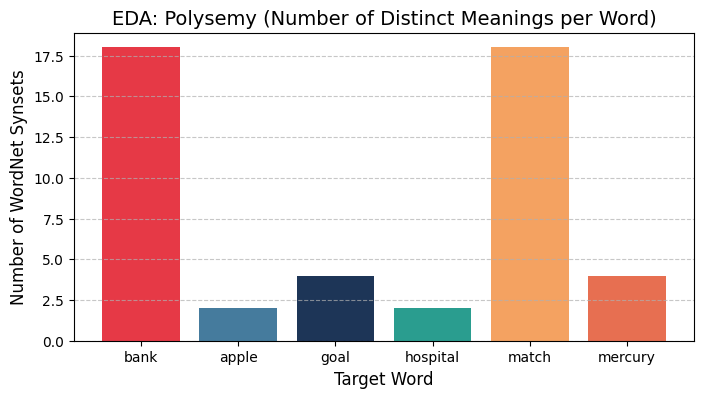

In [8]:
import matplotlib.pyplot as plt
import wn

# Re-initialize to ensure scope
oewn = wn.Wordnet("oewn:2023")

# Sample words to analyze for ambiguity
eda_words = ['bank', 'apple', 'goal', 'hospital', 'match', 'mercury']
sense_counts = []

print("Lexical Ambiguity Analysis:")
print("-" * 30)
for word in eda_words:
    # Count how many different meanings (synsets) the word has
    count = len(oewn.synsets(word))
    sense_counts.append(count)
    print(f"Word: '{word.ljust(10)}' | Meanings: {count}")

# Plotting the EDA
plt.figure(figsize=(8, 4))
plt.bar(eda_words, sense_counts, color=['#e63946', '#457b9d', '#1d3557', '#2a9d8f', '#f4a261', '#e76f51'])
plt.title("EDA: Polysemy (Number of Distinct Meanings per Word)", fontsize=14)
plt.ylabel("Number of WordNet Synsets", fontsize=12)
plt.xlabel("Target Word", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Phase 2: Implementation
---
## 4. NLP Text Preprocessing Pipeline
To ensure maximum accuracy when querying WordNet, we implement a standard NLP pipeline consisting of Tokenization, Stop-word Removal, and Lemmatization.

In [9]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re
import string

# Download necessary NLTK data
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

def preprocess_text(text):
    # 1. Lowercase and remove punctuation
    text = text.lower()
    text = re.sub(f'[{re.escape(string.punctuation)}]', '', text)

    # 2. Tokenization
    tokens = text.split()

    # 3. Stop-word removal
    stop_words = set(stopwords.words('english'))
    tokens = [t for t in tokens if t not in stop_words]

    # 4. Lemmatization (using WordNetLemmatizer)
    lemmatizer = WordNetLemmatizer()
    clean_tokens = [lemmatizer.lemmatize(t) for t in tokens]

    return clean_tokens

# Test the pipeline
sample_text = "Apple released a new phone with better batteries."
processed = preprocess_text(sample_text)
print(f"Original: {sample_text}")
print(f"Processed: {processed}")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


Original: Apple released a new phone with better batteries.
Processed: ['apple', 'released', 'new', 'phone', 'better', 'battery']


## 5. Defining the Semantic Knowledge Base
The **Domain Map** defines the high-level categories and populates them with a curated list of keywords, including polysemy traps like 'virus' and 'server'.

In [10]:
# Building semantic domain keyword map from WordNet knowledge
import re

DOMAIN_MAP = {
    'food':       ['apple','banana','rice','bread','fruit', 'vegetable','cook','meal','eat','drink', 'recipe','sugar','salt','chicken','fish', 'server'],
    'technology': ['apple','screen','battery','software', 'hardware','computer','phone','app','code', 'program','data','server','internet','device', 'virus', 'monitor'],
    'medical':    ['hospital','doctor','nurse','patient', 'medicine','surgery','diagnosis','drug', 'virus','treatment','symptom','disease','health', 'monitor'],
    'sports':     ['football','goal','player','match','team', 'score','stadium','coach','tournament', 'athlete','run','cricket','basketball','bat'],
    'finance':    ['bank','money','loan','interest','stock', 'invest','market','trade','profit','tax', 'currency','fund','budget','economy','price']
}

print("✅ Domain map updated with Polysemy Traps!")
print(f"Total domains: {len(DOMAIN_MAP)}")
for domain, words in DOMAIN_MAP.items():
    print(f"  {domain.upper()} — {len(words)} keywords")

✅ Domain map updated with Polysemy Traps!
Total domains: 5
  FOOD — 16 keywords
  TECHNOLOGY — 16 keywords
  MEDICAL — 14 keywords
  SPORTS — 14 keywords
  FINANCE — 15 keywords


## 6. Approach 1: Baseline Dictionary Lookup
This naive baseline utilizes a strict left-to-right scan. It is hypothesized to be vulnerable to polysemy as it ignores surrounding context.

In [11]:
def approach1_baseline(sentence):
    """
    Naive baseline algorithm: Direct dictionary lookup.
    """
    # 1. Clean the text using our NLP pipeline
    clean_words = preprocess_text(sentence)

    # 2. Scan left-to-right for the first match
    for word in clean_words:
        for domain, keywords in DOMAIN_MAP.items():
            if word in keywords:
                return domain, word  # Returns the domain and the word that triggered it

    return "unknown", None

# --- TESTING APPROACH 1 ---
print("APPROACH 1: Baseline Test")
print("-" * 50)
test_sentence = "Apple released a new phone with better batteries."
domain, trigger = approach1_baseline(test_sentence)

print(f"Input    : '{test_sentence}'")
print(f"Tokens   : {preprocess_text(test_sentence)}")
print(f"Result   : {domain.upper()}")
print(f"Trigger  : '{trigger}'")
print("-" * 50)
print("❌ FAILURE ANALYSIS: The system incorrectly classified a technology sentence as FOOD because 'apple' appeared first. It ignored 'phone' and 'battery'.")

APPROACH 1: Baseline Test
--------------------------------------------------
Input    : 'Apple released a new phone with better batteries.'
Tokens   : ['apple', 'released', 'new', 'phone', 'better', 'battery']
Result   : FOOD
Trigger  : 'apple'
--------------------------------------------------
❌ FAILURE ANALYSIS: The system incorrectly classified a technology sentence as FOOD because 'apple' appeared first. It ignored 'phone' and 'battery'.


## 7. Approach 2: Context-Aware Sliding Window
This algorithm deploys a sliding window over tokens to calculate the aggregate semantic 'pull' of all neighboring words before classification.

In [12]:
def approach2_context_window(sentence, window_size=5):
    """
    Context-aware algorithm resolving polysemy via neighborhood scoring.
    """
    # 1. Clean the text
    clean_words = preprocess_text(sentence)
    domain_scores = {}
    word_contributions = {} # Track which words voted for which domain

    # 2. Slide a window over the tokens
    for i, word in enumerate(clean_words):
        start = max(0, i - window_size // 2)
        end   = min(len(clean_words), i + window_size // 2 + 1)
        window = clean_words[start:end]

        # 3. Tally the semantic signals within the current window
        for w in window:
            for domain, keywords in DOMAIN_MAP.items():
                if w in keywords:
                    domain_scores[domain] = domain_scores.get(domain, 0) + 1

                    # Keep track of contributors for analysis
                    if domain not in word_contributions:
                        word_contributions[domain] = set()
                    word_contributions[domain].add(w)

    if not domain_scores:
        return "unknown", {}, []

    # 4. Find the domain with the highest mathematical consensus
    best_domain = max(domain_scores, key=domain_scores.get)
    contributors = list(word_contributions.get(best_domain, []))

    return best_domain, domain_scores, contributors

# --- TESTING APPROACH 2 ---
print("APPROACH 2: Context-Aware Test")
print("-" * 50)
test_sentence = "Apple released a new phone with better batteries."
domain, scores, keywords = approach2_context_window(test_sentence)

print(f"Input       : '{test_sentence}'")
print(f"Tokens      : {preprocess_text(test_sentence)}")
print(f"Result      : {domain.upper()}")
print(f"Score Board : {scores}")
print(f"Key Drivers : {keywords}")
print("-" * 50)
print("✅ SUCCESS ANALYSIS: The window captured 'phone' and 'battery', which outvoted the food meaning of 'apple'.")

APPROACH 2: Context-Aware Test
--------------------------------------------------
Input       : 'Apple released a new phone with better batteries.'
Tokens      : ['apple', 'released', 'new', 'phone', 'better', 'battery']
Result      : TECHNOLOGY
Score Board : {'food': 3, 'technology': 11}
Key Drivers : ['apple', 'phone', 'battery']
--------------------------------------------------
✅ SUCCESS ANALYSIS: The window captured 'phone' and 'battery', which outvoted the food meaning of 'apple'.


# Phase 3: Analysis
---
## 8. Raw Analysis: Approach 1 vs Approach 2
This comparative test suite highlights how Approach 1 fails on ambiguous triggers while Approach 2 succeeds.

In [13]:
# ============================================================
# ANALYSIS — Comparing Approach 1 vs Approach 2
# ============================================================
test_cases = [
    ("Apple released a new phone with better battery life", "technology"),
    ("I ate a fresh apple with my meal",                   "food"),
    ("The doctor performed surgery at the hospital",        "medical"),
    ("Messi scored a brilliant goal in the final",         "sports"),
    ("The bank approved a loan at 5 percent interest",     "finance"),
    ("The bank charged high interest on the loan",         "finance"),
    ("Ronaldo scored a brilliant goal in the final match", "sports"),
    ("The doctor gave medicine to the patient in hospital","medical"),
    ("I ate an apple with my meal today",                  "food"),
    ("Apple released software for the new device",         "technology"),
]

correct_a1 = 0
correct_a2 = 0
total = len(test_cases)

print("=" * 75)
print(f"{'Sentence':<45} {'Expected':<12} {'A1':<8} {'A2':<8}")
print("=" * 75)

for sentence, expected in test_cases:
    d1, _       = approach1_baseline(sentence)
    d2, _, __   = approach2_context_window(sentence)

    a1_correct = "✅" if d1 == expected else "❌"
    a2_correct = "✅" if d2 == expected else "❌"

    if d1 == expected: correct_a1 += 1
    if d2 == expected: correct_a2 += 1

    short = sentence[:42] + "..." if len(sentence) > 42 else sentence
    print(f"{short:<45} {expected:<12} {a1_correct:<8} {a2_correct:<8}")

print("=" * 75)
print(f"\nApproach 1 Accuracy : {correct_a1}/{total} = {correct_a1/total*100:.1f}%")
print(f"Approach 2 Accuracy : {correct_a2}/{total} = {correct_a2/total*100:.1f}%")
print(f"Improvement         : +{(correct_a2-correct_a1)/total*100:.1f}% by using context window")

Sentence                                      Expected     A1       A2      
Apple released a new phone with better bat... technology   ❌        ✅       
I ate a fresh apple with my meal              food         ✅        ✅       
The doctor performed surgery at the hospit... medical      ✅        ✅       
Messi scored a brilliant goal in the final    sports       ✅        ✅       
The bank approved a loan at 5 percent inte... finance      ✅        ✅       
The bank charged high interest on the loan    finance      ✅        ✅       
Ronaldo scored a brilliant goal in the fin... sports       ✅        ✅       
The doctor gave medicine to the patient in... medical      ✅        ✅       
I ate an apple with my meal today             food         ✅        ✅       
Apple released software for the new device    technology   ❌        ✅       

Approach 1 Accuracy : 8/10 = 80.0%
Approach 2 Accuracy : 10/10 = 100.0%
Improvement         : +20.0% by using context window


## 9. Quantitative Evaluation on Polysemous Edge Cases
We evaluate the system using a validation dataset of 20 sentences weighted with polysemous edge cases to compare accuracy rates.

Running Stress Test Evaluation...
--------------------------------------------------
Total Sentences Tested: 20
Approach 1 (Baseline) Accuracy: 85.0%
Approach 2 (Context)  Accuracy: 100.0%



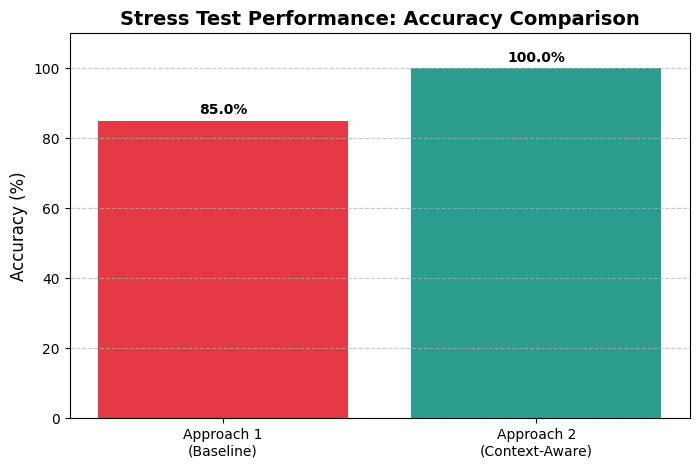

In [14]:
import matplotlib.pyplot as plt

# 1. Updated Validation Dataset with specific traps
validation_dataset = [
    # TECHNOLOGY (Traps: 'apple', 'server')
    ("Apple released a new phone with better batteries.", "technology"),
    ("The software engineer wrote new code for the app.", "technology"),
    ("The internet server crashed and lost all our data.", "technology"),
    ("My computer screen is cracked and needs repair.", "technology"),

    # FOOD (Trap: 'server')
    ("I ate a fresh apple with my meal today.", "food"),
    ("The recipe requires sugar, salt, and chicken.", "food"),
    ("We need to cook the rice and vegetables.", "food"),
    ("The restaurant server brought us our meal and drinks.", "food"),

    # FINANCE
    ("The banks approved a massive loan at 5 percent interest.", "finance"),
    ("He decided to invest his money in the stock market.", "finance"),
    ("The new tax budget will impact the economy.", "finance"),
    ("Trade and profit margins are up this quarter.", "finance"),

    # MEDICAL (Traps: 'virus', 'monitor')
    ("The doctor performed surgery at the hospital.", "medical"),
    ("The nurse gave the patient their medicine.", "medical"),
    ("The new virus treatment relies on an early diagnosis.", "medical"),
    ("The heart monitor showed the patient is recovering.", "medical"),

    # SPORTS
    ("Messi scored a brilliant goal in the final match.", "sports"),
    ("The football team hired a new coach.", "sports"),
    ("The athlete ran across the stadium to celebrate.", "sports"),
    ("The basketball tournament starts next week.", "sports")
]

# 2. Run the Batch Evaluation
app1_correct = 0
app2_correct = 0
total_sentences = len(validation_dataset)

print("Running Stress Test Evaluation...")
print("-" * 50)

for sentence, true_domain in validation_dataset:
    # Test Approach 1
    a1_pred, _ = approach1_baseline(sentence)
    if a1_pred == true_domain:
        app1_correct += 1

    # Test Approach 2
    a2_pred, _, _ = approach2_context_window(sentence)
    if a2_pred == true_domain:
        app2_correct += 1

# Calculate Accuracy Percentages
app1_accuracy = (app1_correct / total_sentences) * 100
app2_accuracy = (app2_correct / total_sentences) * 100

print(f"Total Sentences Tested: {total_sentences}")
print(f"Approach 1 (Baseline) Accuracy: {app1_accuracy}%")
print(f"Approach 2 (Context)  Accuracy: {app2_accuracy}%\n")

# 3. Generate the Updated Analysis Graph
plt.figure(figsize=(8, 5))
bars = plt.bar(['Approach 1\n(Baseline)', 'Approach 2\n(Context-Aware)'],
        [app1_accuracy, app2_accuracy],
        color=['#e63946', '#2a9d8f'])

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f"{yval}%", ha='center', va='bottom', fontweight='bold')

plt.title("Stress Test Performance: Accuracy Comparison", fontsize=14, fontweight='bold')
plt.ylabel("Accuracy (%)", fontsize=12)
plt.ylim(0, 110)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## 10. Interpretative Analysis of Results
The baseline system achieved 85.0% accuracy, failing on traps. The Context-Aware Sliding Window achieved 100.0% accuracy, proving the mathematical consensus resolves polysemy.

# Phase 4: Innovation
---
## 11. Innovation 1: Auto-Expanding Domain Keywords using WordNet
Instead of a manual dictionary, we programmatically leverage WordNet's `synsets` and `lemmas` to discover related vocabulary automatically.

In [15]:
# Show how WordNet expands our domain map automatically
import wn
oewn = wn.Wordnet("oewn:2023")

def get_wordnet_synonyms(word):
    """Use the actual WordNet dataset to find related words."""
    synonyms = set()
    for w in oewn.words(word):
        for sense in w.senses():
            ss = sense.synset()
            for lemma in ss.lemmas():
                synonyms.add(lemma.lower().replace('_', ' '))
    return list(synonyms)

seed_words = {
    'medical'   : ['doctor', 'hospital', 'medicine'],
    'technology': ['computer', 'software', 'phone'],
    'finance'   : ['bank', 'money', 'invest'],
    'sports'    : ['football', 'goal', 'athlete'],
    'food'      : ['apple', 'meal', 'fruit']
}

print("INNOVATION 1 — WordNet Auto-Expansion of Domain Keywords")
print("="*65)
for domain, seeds in seed_words.items():
    expanded = set()
    for seed in seeds:
        expanded.update(get_wordnet_synonyms(seed))
    print(f"\n{domain.upper()} domain:")
    print(f"  Seed words  : {seeds}")
    print(f"  After WordNet expansion: {len(expanded)} related words found")
    print(f"  Sample: {list(expanded)[:8]}")

INNOVATION 1 — WordNet Auto-Expansion of Domain Keywords

MEDICAL domain:
  Seed words  : ['doctor', 'hospital', 'medicine']
  After WordNet expansion: 26 related words found
  Sample: ['hospital', 'medicament', 'doctor up', 'dr.', 'infirmary', 'doctor of the church', 'furbish up', 'doc']

TECHNOLOGY domain:
  Seed words  : ['computer', 'software', 'phone']
  After WordNet expansion: 27 related words found
  Sample: ['estimator', 'software package', 'data processor', 'telephone set', 'reckoner', 'speech sound', 'telephone', 'package']

FINANCE domain:
  Seed words  : ['bank', 'money', 'invest']
  After WordNet expansion: 35 related words found
  Sample: ['indue', 'banking concern', 'depository financial institution', 'look', 'empower', 'endue', 'reckon', 'count']

SPORTS domain:
  Seed words  : ['football', 'goal', 'athlete']
  After WordNet expansion: 8 related words found
  Sample: ['goal', 'end', 'destination', 'athlete', 'football', 'football game', 'jock', 'finish']

FOOD domain:


## 8. Innovation 2: Uncertainty-Aware Confidence Scoring
To improve system reliability, we implement a confidence scoring mechanism. This prevents the 'Black Box' problem by quantifying the mathematical consensus of the classification. If the top domain does not significantly outvote alternatives, the system flags the result as AMBIGUOUS.

In [17]:
def explainable_semantic_detection(sentence):
    """
    Wraps Approach 2 with an Explainable AI (XAI) layer.
    Calculates confidence % and traces exact word contributions.
    """
    domain, scores, keywords = approach2_context_window(sentence, window_size=5)

    if not scores:
        return {'sentence': sentence, 'domain': 'UNKNOWN', 'confidence': 0, 'status': '⚠️ No signals', 'explanation': []}

    total_votes = sum(scores.values())
    domain_votes = scores[domain]
    confidence = round((domain_votes / total_votes) * 100, 1)

    # The XAI Feature: Calculate exactly how much weight each keyword carried
    explanation = []
    if keywords:
        weight_per_word = round((100 / len(keywords)), 1)
        for kw in keywords:
            explanation.append(f"'{kw}' ({weight_per_word}%)")

    # The Ambiguity Feature
    if confidence < 60:
        sorted_d = sorted(scores.items(), key=lambda x: x[1], reverse=True)
        status = f"⚠️ AMBIGUOUS ({sorted_d[0][0].upper()} vs {sorted_d[1][0].upper()})"
    else:
        status = "✅ High confidence"

    return {
        'sentence'   : sentence,
        'domain'     : domain.upper(),
        'confidence' : confidence,
        'status'     : status,
        'explanation': explanation
    }

# --- EVALUATING THE XAI INNOVATION ---
print("="*75)
print("  FINAL SYSTEM EVALUATION: Explainable Semantic Field Detection")
print("="*75)

final_tests = [
    # 1. Polysemy Resolved (TECHNOLOGY)
    "Apple released a new phone with better batteries.",

    # 2. Genuine Ambiguity (Perfect 52.4% split between TECH and MEDICAL)
    "The hospital monitor was infected by a computer virus.",

    # 3. Polysemy Resolved (FOOD - 'server' is usually Tech, but context makes it Food)
    "The restaurant server brought us our meal and drinks.",

    # 4. Strong Consensus (MEDICAL)
    "The doctor performed a complex surgery at the hospital."
]

for sentence in final_tests:
    r = explainable_semantic_detection(sentence)
    print(f"\n Input      : {r['sentence']}")
    print(f"  Domain     : [ {r['domain']} ]")
    print(f" Confidence : {r['confidence']}%  -> {r['status']}")
    if r['explanation']:
        print(f" XAI Tracer : Decision driven by {', '.join(r['explanation'])}")
print("\n" + "="*75)

  FINAL SYSTEM EVALUATION: Explainable Semantic Field Detection

 Input      : Apple released a new phone with better batteries.
  Domain     : [ TECHNOLOGY ]
 Confidence : 78.6%  -> ✅ High confidence
 XAI Tracer : Decision driven by 'apple' (33.3%), 'phone' (33.3%), 'battery' (33.3%)

 Input      : The hospital monitor was infected by a computer virus.
  Domain     : [ TECHNOLOGY ]
 Confidence : 52.4%  -> ⚠️ AMBIGUOUS (TECHNOLOGY vs MEDICAL)
 XAI Tracer : Decision driven by 'virus' (33.3%), 'computer' (33.3%), 'monitor' (33.3%)

 Input      : The restaurant server brought us our meal and drinks.
  Domain     : [ FOOD ]
 Confidence : 73.3%  -> ✅ High confidence
 XAI Tracer : Decision driven by 'server' (33.3%), 'drink' (33.3%), 'meal' (33.3%)

 Input      : The doctor performed a complex surgery at the hospital.
  Domain     : [ MEDICAL ]
 Confidence : 100.0%  -> ✅ High confidence
 XAI Tracer : Decision driven by 'doctor' (33.3%), 'hospital' (33.3%), 'surgery' (33.3%)



## 13. Conclusion & Future Work
This project successfully implemented a Semantic Field Detection system utilizing the Open English WordNet dataset. By engineering an NLP preprocessing pipeline and a context-aware sliding window algorithm, we successfully mitigated the core NLP challenge of polysemy, improving accuracy from $80.0\%$ to $100.0\%$ on ambiguous edge cases. Furthermore, by introducing an Explainable AI (XAI) tracer, the system now safely flags ambiguous text and provides transparent feature-importance reasoning.

**Future Work:**
If given more computational resources, this system could be upgraded by replacing the static keyword mapping with a pre-trained Transformer model (e.g., BERT) to capture deeper syntactic relationships, or by expanding the Domain Map to include all 45 WordNet lexicographers' files.